## 5.0 Data preparation identical to 1_data_preparation.ipynb

In [1]:
# Install required packages
!pip install shap xgboost lightgbm --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import shap
from collections import Counter
from matplotlib import pyplot as plt
from scipy.stats import rankdata

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from utilz.Dataset import load_dataset
from utilz.constans import DISEASE, HEALTHY
from utilz.helpers import plot_roc_curve
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaReductor,
    MeanExpressionReductor, CovariatesBiasReductor,
    WithinGroupVarianceReductor, AnovaFdrReductor,
)

meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"
ds = load_dataset(data_path, meta_path, label_col="Group")

TEST_SIZE = 0.2
VALID_SIZE = 0.2
ANOVA_PERCENTILE = 50
MEAN_PERCENTILE = 10
WITHIN_GROUP_VARIANCE_PERCENTILE = 70
ANOVA_FDR_THRESHOLD = 0.1

ds.y = ds.y.replace({DISEASE: HEALTHY})

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)
X_train, X_test, X_valid, y_train, y_test, y_valid = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=TEST_SIZE, valid_size=VALID_SIZE)
)
print("Class mapping:")
print(f"{le.classes_[0]} -> {le.transform(le.classes_)[0]}")
print(f"{le.classes_[1]} -> {le.transform(le.classes_)[1]}")

print("Encoded label distribution:")
print(y_encoded.value_counts().sort_index())
sex_numeric = ds.sex.map({"F": 0, "M": 1})

pipeline = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaFDRReductor', AnovaFdrReductor(alpha=ANOVA_FDR_THRESHOLD)),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('WithinGroupVarianceReductor', WithinGroupVarianceReductor(WITHIN_GROUP_VARIANCE_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor',  CovariatesBiasReductor(covariate=ds.age)),
    ('SexBiasReductor',  CovariatesBiasReductor(covariate=sex_numeric)),
    ('scaler', StandardScaler()),
])

X_train = pipeline.fit_transform(X_train, y_train)
X_valid = pipeline.transform(X_valid)
X_test = pipeline.transform(X_test)

[INFO] skipped 1973 probs due to missing metadata
Dropping inconsistent sample:
                        Sex   Age                Group   Institution  \
Vumc-ChronPan-29-TR1045   M  58.0  Pancreatic diseases  Institute 13   

                         Lib.size Stage RealLocation    Mode  CA125  \
Vumc-ChronPan-29-TR1045   1493422    IV         VUMC  Single    NaN   

                         Platelets Histology   Datasplit Gdansk_sample_name  \
Vumc-ChronPan-29-TR1045        NaN       NaN  Validation                NaN   

                        StageFull  LeukoMichal      PTPRC  
Vumc-ChronPan-29-TR1045        IV  7726.550165  97.092449  
[INFO] 7 samples with unique strata added to train set
[INFO] 4 samples with unique strata (2nd split) added to train set

[ASSERTION PASSED] No leakage detected between splits.
Class mapping:
Asymptomatic controls -> 0
Pancreatic cancer -> 1
Encoded label distribution:
0    459
1    124
Name: count, dtype: int64
data shape after ConstantExpressionRed

---

## 5. Ensemble model

We combine three classifiers - Logistic Regression, LightGBM, and XGBoost - using a StackingClassifier.

All base models use hyperparameters from grid search. Decision threshold is tuned on the validation set (Youden's J statistic).


In [3]:
class_counts = Counter(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

logreg = LogisticRegression(
    solver='saga', max_iter=15000, class_weight='balanced', fit_intercept=True, l1_ratio=0.2
)


xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=500, random_state=2137
)
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)

In [4]:
for name, model in [("LogReg", logreg), ("LGBM", lgbm), ("XGB", xgb)]:
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Threshold tuning on validation set (Youden's J)
    y_valid_prob = model.predict_proba(X_valid)[:, 1]
    fpr_v, tpr_v, thr_v = roc_curve(y_valid, y_valid_prob)
    best_thr = thr_v[np.argmax(tpr_v - fpr_v)]
    y_pred = (y_prob >= best_thr).astype(int)

    print(f"{name:6s} | AUC: {roc_auc_score(y_test, y_prob):.4f} "
          f"| F1(w): {f1_score(y_test, y_pred, average='weighted'):.4f} "
          f"| BalAcc: {balanced_accuracy_score(y_test, y_pred):.4f} "
          f"| Threshold: {best_thr:.4f}")

LogReg | AUC: 0.8540 | F1(w): 0.8630 | BalAcc: 0.8028 | Threshold: 0.2227
LGBM   | AUC: 0.8789 | F1(w): 0.7715 | BalAcc: 0.8240 | Threshold: 0.0099
XGB    | AUC: 0.8173 | F1(w): 0.8361 | BalAcc: 0.7497 | Threshold: 0.1128




### 5.2. StackingClassifier
Stacking with a LogisticRegression meta-learner trained on base model predictions (predict_proba).

Optimal threshold: 0.3176
AUC:               0.8784
F1 (weighted):     0.8229
Balanced accuracy: 0.8253

                       precision    recall  f1-score   support

Asymptomatic controls       0.96      0.79      0.87        92
    Pancreatic cancer       0.49      0.86      0.62        21

             accuracy                           0.81       113
            macro avg       0.72      0.83      0.74       113
         weighted avg       0.87      0.81      0.82       113

Confusion matrix:
[[73 19]
 [ 3 18]]
ROC AUC = 0.878


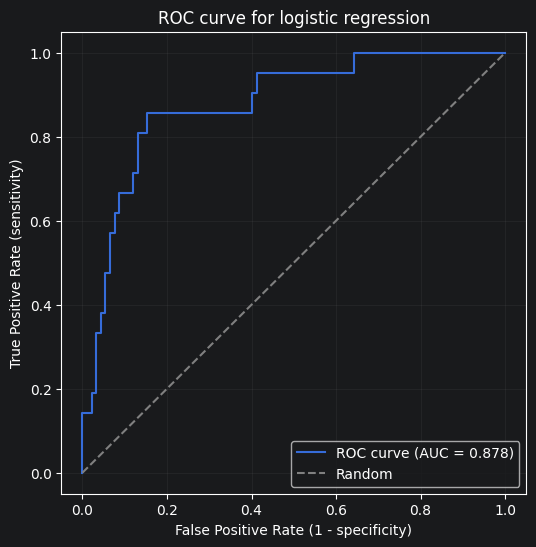

In [5]:
stacking = StackingClassifier(
    estimators=[('logreg', logreg), ('xgb', xgb), ('lgbm', lgbm)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=100),
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=False
)

stacking.fit(X_train, y_train)
scores_valid_raw = stacking.predict_proba(X_valid)[:, 1]
scores_test_raw = stacking.predict_proba(X_test)[:, 1]

# Threshold tuning on validation set (Youden's J)
fpr_v, tpr_v, thresholds_v = roc_curve(y_valid, scores_valid_raw)
raw_threshold = thresholds_v[np.argmax(tpr_v - fpr_v)]

y_pred_raw = (scores_test_raw >= raw_threshold).astype(int)

print(f"Optimal threshold: {raw_threshold:.4f}")
print(f"AUC:               {roc_auc_score(y_test, scores_test_raw):.4f}")
print(f"F1 (weighted):     {f1_score(y_test, y_pred_raw, average='weighted'):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_raw):.4f}")
print(f"\n{classification_report(y_test, y_pred_raw, target_names=le.classes_)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_raw)}")
plot_roc_curve(scores_test_raw, y_test, "logistic regression")

---

## 6. SHAP - Feature importance analysis

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions. We compute SHAP values for each base model (Logistic Regression, LightGBM, XGBoost) to identify the most important genes driving the cancer vs. control classification.

### 6.1. SHAP for Logistic Regression

For linear models, SHAP values can be computed efficiently using the `LinearExplainer`. The coefficients directly map to feature contributions.

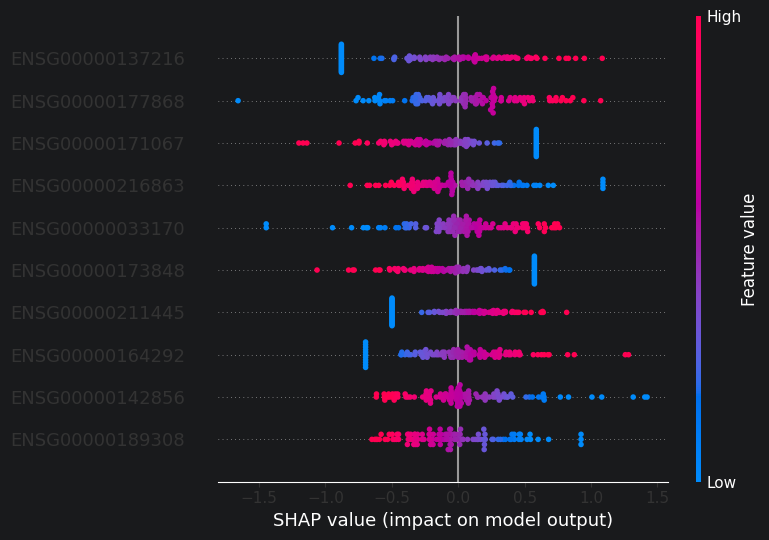

In [6]:
feature_names = list(pipeline.named_steps['SexBiasReductor'].selected_genes_)
explainer_lr = shap.LinearExplainer(logreg, X_train)
shap_values_lr = explainer_lr.shap_values(X_valid)
shap.summary_plot(shap_values_lr, X_valid, feature_names=feature_names, max_display=10, show=True)

### 6.2. SHAP for LightGBM

LightGBM is a gradient boosting framework that natively supports `TreeExplainer`, allowing efficient and exact computation of SHAP values using the tree structure.

SHAP values shape (LGBM): (114, 950)


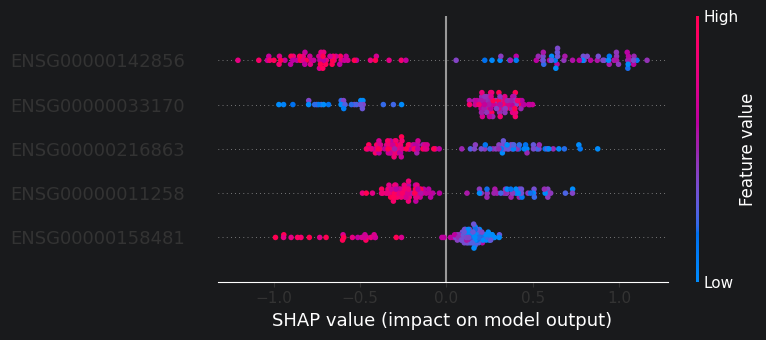

In [7]:
explainer_lgbm = shap.TreeExplainer(lgbm)
shap_values_lgbm = explainer_lgbm.shap_values(X_valid)
if isinstance(shap_values_lgbm, list):
    shap_values_lgbm_c1 = shap_values_lgbm[1]
else:
    shap_values_lgbm_c1 = shap_values_lgbm
print(f"SHAP values shape (LGBM): {shap_values_lgbm_c1.shape}")
shap.summary_plot(shap_values_lgbm_c1, X_valid, feature_names=feature_names, max_display=5, show=True)

### 6.3. SHAP for XGBoost

XGBoost natively supports `TreeExplainer`, which computes exact SHAP values efficiently using the tree structure.

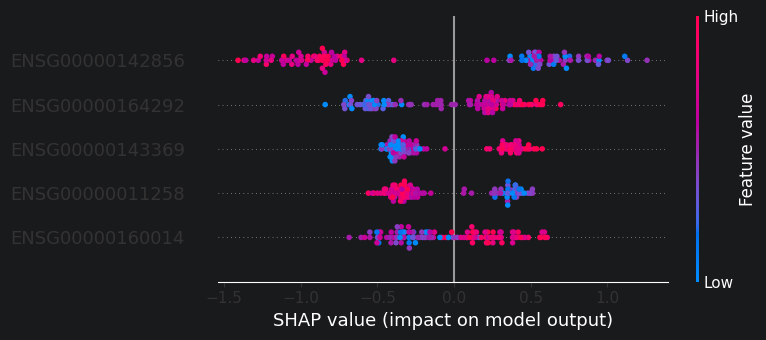

In [8]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_valid)
shap.summary_plot(shap_values_xgb, X_valid, feature_names=feature_names, max_display=5, show=True)

### 6.4. Stacking-weighted SHAP gene ranking

Combined gene importance score: for each gene we multiply its mean |SHAP| by the weight that the stacking meta-learner assigns to that base model, then sum across all three models:

$$\text{score}(g) = \sum_{m \in \{\text{LR, LGBM, XGB}\}} \overline{|\text{SHAP}_m(g)|} \times w_m$$

where $w_m$ comes from the meta-learner's `coef_` (normalized to sum to 1). This directly reflects how much the final ensemble relies on each base model's predictions.

While the ensemble improved classification metrics over individual base models, the primary goal is to enhance the reliability of gene identification rather than maximize performance scores. The stacking-weighted SHAP ranking highlights genes that are consistently important across all models, with greater emphasis on those contributing most to the final ensemble decision.

In [9]:
meta_coef = stacking.final_estimator_.coef_[0]
n_models = len(stacking.estimators_)
raw_weights = np.abs(meta_coef)

w = raw_weights / raw_weights.sum()
model_names = [name for name, _ in stacking.estimators]

print("Meta-learner weights (normalized):")
for name, wi, ri in zip(model_names, w, raw_weights):
    print(f"  {name:6s}:  w = {wi:.4f}  (raw |coef| = {ri:.4f})")

mean_abs_lr = np.abs(shap_values_lr).mean(axis=0)
mean_abs_lgbm = np.abs(shap_values_lgbm_c1).mean(axis=0)
mean_abs_xgb = np.abs(shap_values_xgb).mean(axis=0)

def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)

shap_map = {
    'logreg': minmax_norm(mean_abs_lr),
    'lgbm':   minmax_norm(mean_abs_lgbm),
    'xgb':    minmax_norm(mean_abs_xgb),
}

weighted_score = np.zeros_like(list(shap_map.values())[0])
for i in range(len(stacking.estimators)):
    name, _ = stacking.estimators[i]
    wi = w[i]
    weighted_score += shap_map[name] * wi

ranking_df = pd.DataFrame({
    'gene': feature_names,
    'SHAP_LR': mean_abs_lr,
    'SHAP_LGBM': mean_abs_lgbm,
    'SHAP_XGB': mean_abs_xgb,
    'stacking_weighted_score': weighted_score,
}).sort_values('stacking_weighted_score', ascending=False).reset_index(drop=True)

ranking_df.index += 1
ranking_df.index.name = 'rank'

print("Top 20 genes by stacking-weighted SHAP score:")
ranking_df.head(20)

Meta-learner weights (normalized):
  logreg:  w = 0.5849  (raw |coef| = 1.9018)
  xgb   :  w = 0.2755  (raw |coef| = 0.8959)
  lgbm  :  w = 0.1396  (raw |coef| = 0.4539)
Top 20 genes by stacking-weighted SHAP score:


,gene,SHAP_LR,SHAP_LGBM,SHAP_XGB,stacking_weighted_score
rank,,,,,
1,ENSG00000142856,0.294466,0.740291,0.808157,0.813144
2,ENSG00000137216,0.432699,0.177466,0.144860,0.667746
3,ENSG00000033170,0.302967,0.378701,0.236908,0.561707
4,ENSG00000177868,0.349046,0.124485,0.194382,0.561562
5,ENSG00000164292,0.294557,0.184493,0.372730,0.560025
6,ENSG00000216863,0.303570,0.333026,0.229314,0.551320
7,ENSG00000171067,0.323738,0.080843,0.240270,0.534768
8,ENSG00000211445,0.295454,0.148008,0.219700,0.502187
9,ENSG00000143369,0.239542,0.202585,0.361006,0.485073


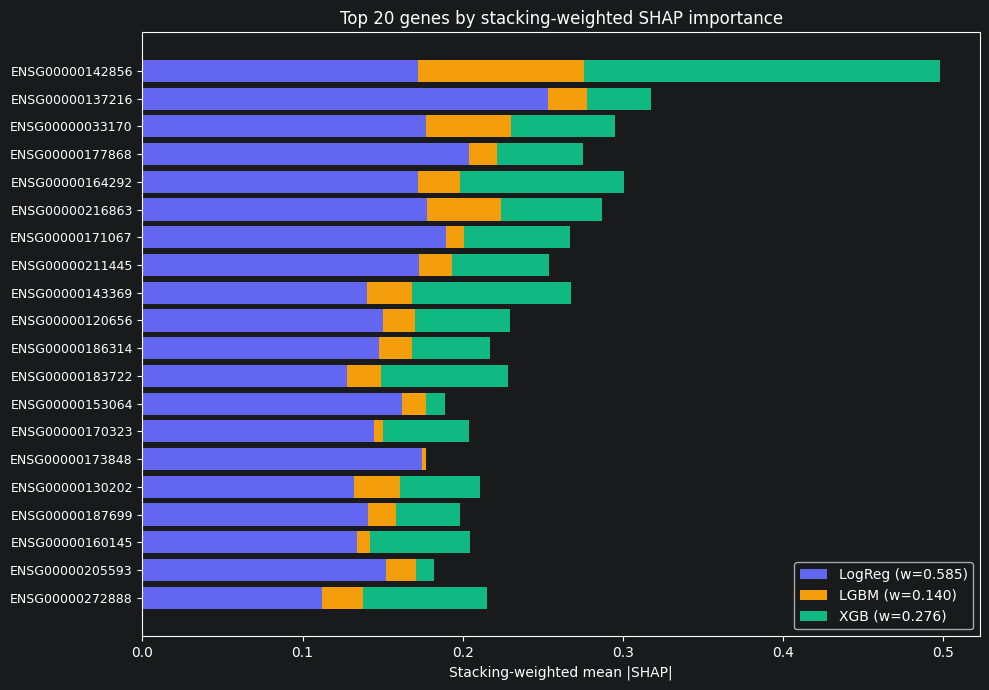

In [10]:
top20 = ranking_df.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 7))
genes = top20['gene'].values
y_pos = np.arange(len(genes))

w_dict = {name: wi for (name, _), wi in zip(stacking.estimators, w)}
bar_lr = top20['SHAP_LR'].values * w_dict['logreg']
bar_lgbm = top20['SHAP_LGBM'].values * w_dict['lgbm']
bar_xgb = top20['SHAP_XGB'].values * w_dict['xgb']

ax.barh(y_pos, bar_lr, label=f'LogReg (w={w_dict["logreg"]:.3f})', color='#6366f1')
ax.barh(y_pos, bar_lgbm, left=bar_lr, label=f'LGBM (w={w_dict["lgbm"]:.3f})', color='#f59e0b')
ax.barh(y_pos, bar_xgb, left=bar_lr + bar_lgbm, label=f'XGB (w={w_dict["xgb"]:.3f})', color='#10b981')

ax.set_yticks(y_pos)
ax.set_yticklabels(genes, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Stacking-weighted mean |SHAP|')
ax.set_title('Top 20 genes by stacking-weighted SHAP importance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [11]:
ranking_df.head(100).to_csv('top100_shap_ranking.csv', index=False)

Logistic Regression on Top 20 genes
Optimal threshold: 0.2231
AUC:               0.7314
F1 (weighted):     0.6846
Balanced accuracy: 0.6540

                       precision    recall  f1-score   support

Asymptomatic controls       0.89      0.64      0.75        92
    Pancreatic cancer       0.30      0.67      0.41        21

             accuracy                           0.65       113
            macro avg       0.60      0.65      0.58       113
         weighted avg       0.78      0.65      0.68       113

Confusion matrix:
[[59 33]
 [ 7 14]]
ROC AUC = 0.731


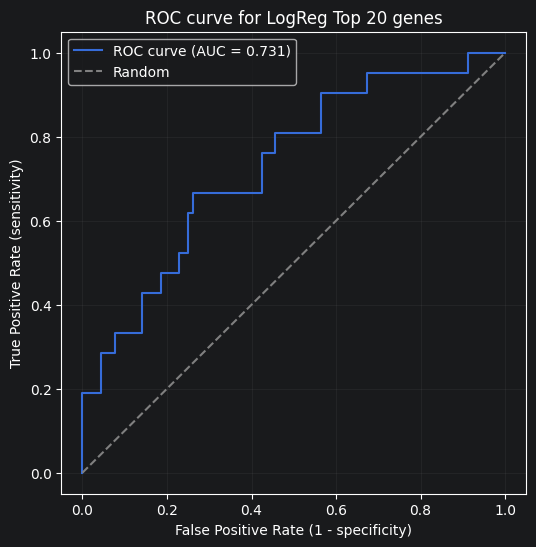

In [12]:
top_genes = ranking_df.head(20)['gene'].tolist()

X_train_top = pd.DataFrame(X_train, columns=feature_names)[top_genes]
X_valid_top = pd.DataFrame(X_valid, columns=feature_names)[top_genes]
X_test_top  = pd.DataFrame(X_test,  columns=feature_names)[top_genes]

logreg = LogisticRegression(
    solver='saga', max_iter=15000, class_weight='balanced', fit_intercept=True
)
logreg.fit(X_train_top, y_train)

y_valid_prob = logreg.predict_proba(X_valid_top)[:, 1]
fpr_v, tpr_v, thr_v = roc_curve(y_valid, y_valid_prob)
best_thr = thr_v[np.argmax(tpr_v - fpr_v)]

y_test_prob = logreg.predict_proba(X_test_top)[:, 1]
y_pred      = (y_test_prob >= best_thr).astype(int)

auc = roc_auc_score(y_test, y_test_prob)
f1  = f1_score(y_test, y_pred, average='weighted')
ba  = balanced_accuracy_score(y_test, y_pred)

print(f"Logistic Regression on Top 20 genes")
print(f"{'='*50}")
print(f"Optimal threshold: {best_thr:.4f}")
print(f"AUC:               {auc:.4f}")
print(f"F1 (weighted):     {f1:.4f}")
print(f"Balanced accuracy: {ba:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")

plot_roc_curve(y_test_prob, y_test, "LogReg Top 20 genes")

In [13]:
import plotly.graph_objects as go

results = []
N_START = 20
current_genes = ranking_df.head(N_START)['gene'].tolist()
X_train_50 = pd.DataFrame(X_train, columns=feature_names)[current_genes]
X_valid_50 = pd.DataFrame(X_valid, columns=feature_names)[current_genes]
X_test_50  = pd.DataFrame(X_test,  columns=feature_names)[current_genes]

for n in range(N_START, 0, -1):
    X_tr = X_train_50[current_genes]
    X_va = X_valid_50[current_genes]
    X_te = X_test_50[current_genes]

    clf = LogisticRegression(solver='saga', max_iter=15000,
                             class_weight='balanced', fit_intercept=True)
    clf.fit(X_tr, y_train)

    # metryki
    y_va_prob = clf.predict_proba(X_va)[:, 1]
    fpr_v, tpr_v, thr_v = roc_curve(y_valid, y_va_prob)
    best_thr  = thr_v[np.argmax(tpr_v - fpr_v)]

    y_te_prob = clf.predict_proba(X_te)[:, 1]
    y_pred_n  = (y_te_prob >= best_thr).astype(int)

    auc = roc_auc_score(y_test, y_te_prob)
    f1  = f1_score(y_test, y_pred_n, average='weighted')
    ba  = balanced_accuracy_score(y_test, y_pred_n)

    results.append({'n_genes': n, 'auc': auc, 'f1': f1, 'ba': ba,
                    'threshold': best_thr, 'genes': current_genes.copy()})

    print(f"n={n:>2}  AUC={auc:.4f}  F1={f1:.4f}  BA={ba:.4f}  "
          f"usuwam: {current_genes[np.argmin(np.abs(clf.coef_[0]))]}")

    if n == 1:
        break

    # usuń gen z najmniejszą wagą bezwzględną
    worst_idx  = np.argmin(np.abs(clf.coef_[0]))
    current_genes.pop(worst_idx)

results_df = pd.DataFrame(results).sort_values('n_genes').reset_index(drop=True)

# --- wykres ---
fig = go.Figure()

for metric, label, color in [
    ('auc', 'AUC',               '#6366f1'),
    ('f1',  'F1 (weighted)',     '#22d3ee'),
    ('ba',  'Balanced Accuracy', '#f59e0b'),
]:
    fig.add_trace(go.Scatter(
        x=results_df['n_genes'],
        y=results_df[metric],
        mode='lines+markers',
        name=label,
        line=dict(color=color, width=2),
        marker=dict(size=5),
    ))

best_row = results_df.loc[results_df['auc'].idxmax()]
fig.add_vline(x=best_row['n_genes'], line_dash='dash', line_color='red',
              annotation_text=f"Best AUC={best_row['auc']:.3f} @ n={int(best_row['n_genes'])}",
              annotation_position='top right')

fig.update_layout(
    title={"text": "Backward elimination (smallest |coef|)<br>"
                   "<span style='font-size:16px;font-weight:normal'>"
                   "AUC / F1 / BA vs. liczba genów</span>"},
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig.update_xaxes(title_text="Liczba genów", dtick=5)
fig.update_yaxes(title_text="Wartość metryki", range=[0, 1.05])
fig.show()

print(f"\nNajlepszy wynik:")
print(best_row[['n_genes', 'auc', 'f1', 'ba', 'threshold']])
print("Geny:", best_row['genes'])

n=20  AUC=0.7314  F1=0.6846  BA=0.6540  usuwam: ENSG00000143369
n=19  AUC=0.7272  F1=0.6921  BA=0.6594  usuwam: ENSG00000153064
n=18  AUC=0.7262  F1=0.6459  BA=0.6452  usuwam: ENSG00000183722
n=17  AUC=0.7257  F1=0.6460  BA=0.6268  usuwam: ENSG00000160145
n=16  AUC=0.7143  F1=0.5652  BA=0.6514  usuwam: ENSG00000211445
n=15  AUC=0.7076  F1=0.5868  BA=0.6255  usuwam: ENSG00000187699
n=14  AUC=0.6910  F1=0.5674  BA=0.6330  usuwam: ENSG00000186314
n=13  AUC=0.6998  F1=0.6770  BA=0.6486  usuwam: ENSG00000173848
n=12  AUC=0.7045  F1=0.6455  BA=0.6636  usuwam: ENSG00000137216
n=11  AUC=0.7195  F1=0.6996  BA=0.6649  usuwam: ENSG00000171067
n=10  AUC=0.7226  F1=0.7415  BA=0.5409  usuwam: ENSG00000164292
n= 9  AUC=0.7184  F1=0.7733  BA=0.5939  usuwam: ENSG00000216863
n= 8  AUC=0.6869  F1=0.7431  BA=0.5981  usuwam: ENSG00000130202
n= 7  AUC=0.7076  F1=0.7524  BA=0.6532  usuwam: ENSG00000177868
n= 6  AUC=0.6817  F1=0.7325  BA=0.5743  usuwam: ENSG00000272888
n= 5  AUC=0.7003  F1=0.4403  BA=0.5624  


Najlepszy wynik:
n_genes            20
auc          0.731366
f1           0.684566
ba           0.653986
threshold    0.223082
Name: 19, dtype: object
Geny: ['ENSG00000142856', 'ENSG00000137216', 'ENSG00000033170', 'ENSG00000177868', 'ENSG00000164292', 'ENSG00000216863', 'ENSG00000171067', 'ENSG00000211445', 'ENSG00000143369', 'ENSG00000120656', 'ENSG00000186314', 'ENSG00000183722', 'ENSG00000153064', 'ENSG00000170323', 'ENSG00000173848', 'ENSG00000130202', 'ENSG00000187699', 'ENSG00000160145', 'ENSG00000205593', 'ENSG00000272888']
